,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Missing values per column:


,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


Total missing values in the DataFrame: 0
Shape of DataFrame before removing duplicates: (10000, 12)
Shape of DataFrame after removing duplicates: (10000, 12)
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+

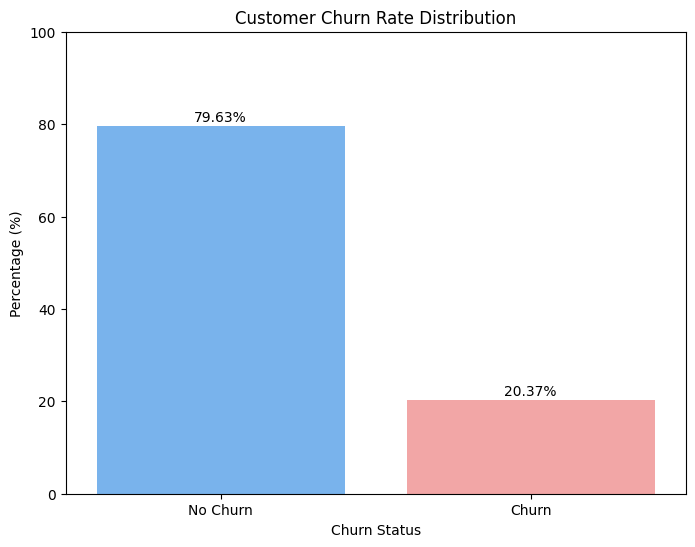

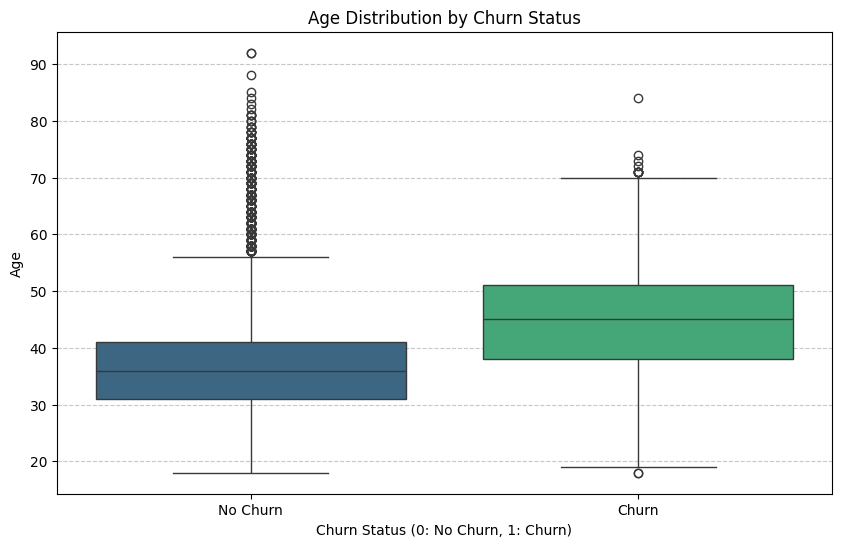

<Figure size 1000x600 with 0 Axes>

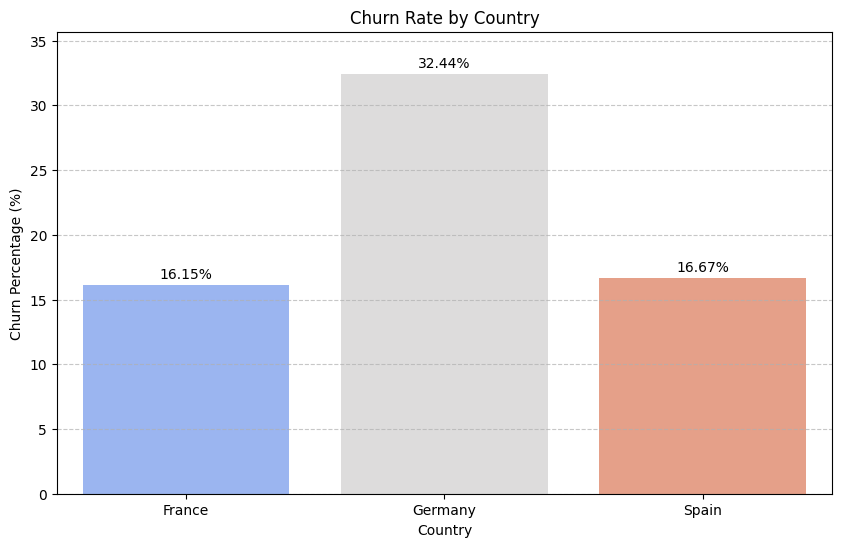

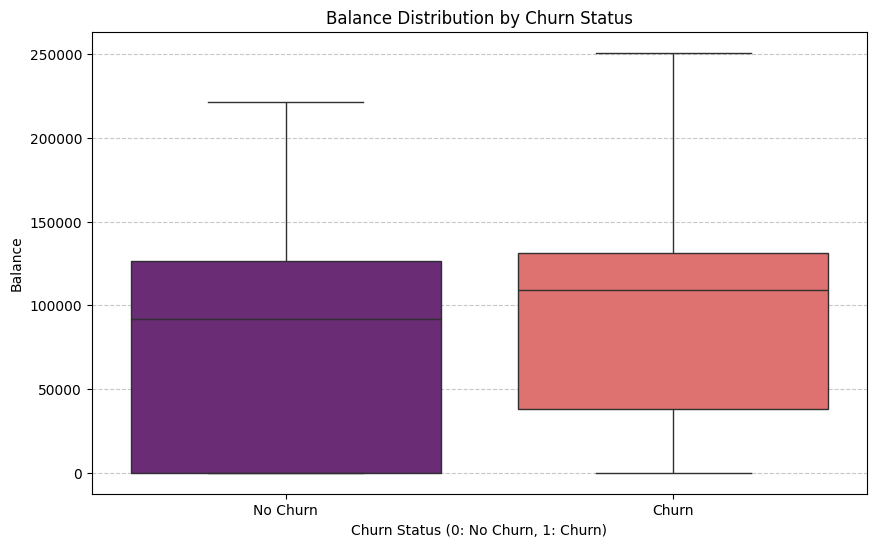

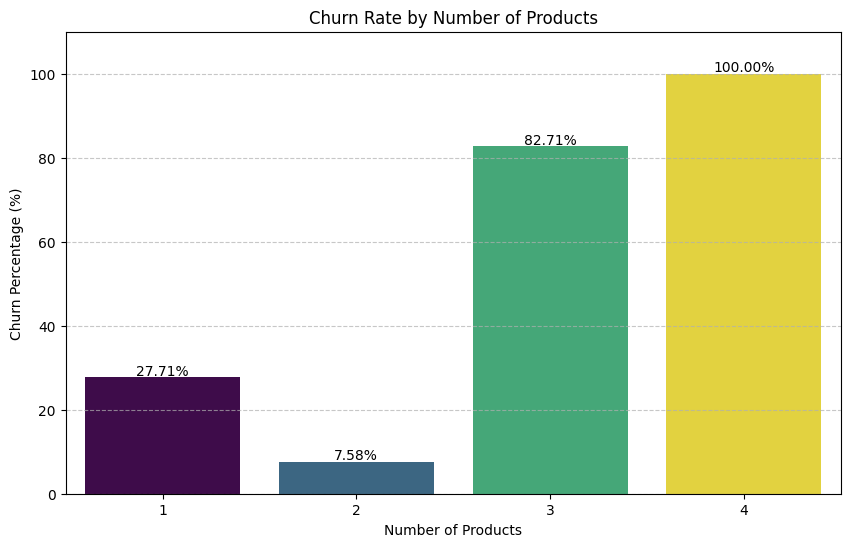

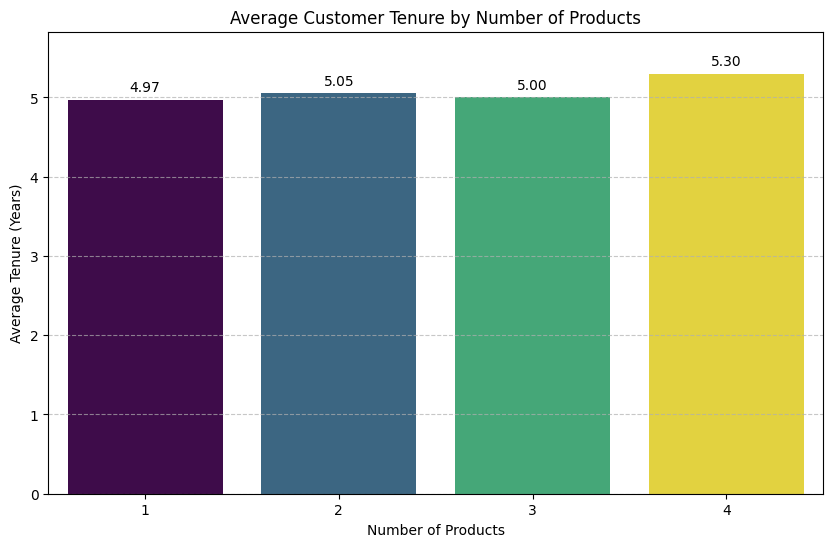

In [ ]:
from numpy import average
import pandas as pd

#import Dataset
df = pd.read_csv('/content/Bank_Customer_Churn_Prediction.csv')
display(df.head())

#Check missing values
print('Missing values per column:')
display(df.isnull().sum())
print(f'Total missing values in the DataFrame: {df.isnull().sum().sum()}')

#remove duplicates
print(f"Shape of DataFrame before removing duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after removing duplicates: {df.shape}")

#data types
print('DataFrame Info:')
df.info()

#Statistics

#Mean age
mean_age = int(df['age'].mean())
print(f"The mean age of customers is: {mean_age}")

#Average Balance
average_balance = average(df['balance'])
print(f"The average balance of customer is: {average_balance:.2f}")

#Churn Rate
churn_counts = df['churn'].value_counts(normalize=True) * 100
print(f"Churn Rate:\n{churn_counts[1]:.2f}%")

#Explonatory Data Analysis

#Churt Rate
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
churn_df = pd.DataFrame({'Category': ['No Churn', 'Churn'], 'Percentage': churn_counts.values})

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Category', y='Percentage', data=churn_df, palette=['#66b3ff', '#ff9999'], hue='Category', legend=False)

# Add labels and title
plt.title('Customer Churn Rate Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100

# Add percentage values on top of the bars
for index, row in churn_df.iterrows():
    plt.text(row.name, row.Percentage + 1, f'{row.Percentage:.2f}%', color='black', ha="center")

plt.show()

#Churn By Age
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='age', data=df, palette='viridis', hue='churn', legend=False)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Churn Status (0: No Churn, 1: Churn)')
plt.ylabel('Age')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Churn By Country
plt.figure(figsize=(10,6))
churn_by_country = df.groupby('country')['churn'].mean().reset_index()
churn_by_country['churn_percentage'] = churn_by_country['churn'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='churn_percentage', data=churn_by_country, palette='coolwarm', hue='country', legend=False)
plt.title('Churn Rate by Country')
plt.xlabel('Country')
plt.ylabel('Churn Percentage (%)')
plt.ylim(0, churn_by_country['churn_percentage'].max() * 1.1) # Set y-limit slightly above max for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage values on top of the bars
for index, row in churn_by_country.iterrows():
    plt.text(row.name, row.churn_percentage + 0.5, f'{row.churn_percentage:.2f}%', color='black', ha="center")

plt.show()

#Churn By Balance
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='balance', data=df, palette='magma', hue='churn', legend=False)
plt.title('Balance Distribution by Churn Status')
plt.xlabel('Churn Status (0: No Churn, 1: Churn)')
plt.ylabel('Balance')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Churn By Number of products
plt.figure(figsize=(10, 6))
churn_by_products = df.groupby('products_number')['churn'].mean().reset_index()
churn_by_products['churn_percentage'] = churn_by_products['churn'] * 100

sns.barplot(x='products_number', y='churn_percentage', data=churn_by_products, palette='viridis', hue='products_number', legend=False)
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Percentage (%)')
plt.ylim(0, churn_by_products['churn_percentage'].max() * 1.1) # Set y-limit slightly above max for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage values on top of the bars
for index, row in churn_by_products.iterrows():
    plt.text(row.name, row.churn_percentage + 0.5, f'{row.churn_percentage:.2f}%', color='black', ha="center")

plt.show()
